# Wind & Seismic Energy Analysis
Casey Skiway AWS station vs seismic energy

In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from obspy import read, UTCDateTime, Stream
from obspy.signal.filter import bandpass as obspy_bp

import itertools
import random
from scipy.stats import linregress

import yaml

with open("config.yml", "r") as f:
    config = yaml.safe_load(f)

aws_dir  = Path(config["aws_dir"])
seis_dir = Path(config["seis_dir"])

In [53]:
id_code = "55510926053"
station = "300060"  # Casey Skiway

csv_path = aws_dir / f"HM01X_Data_{station}_{id_code}.txt"

df = pd.read_csv(csv_path, low_memory=False)

df["datetime"] = pd.to_datetime(
    dict(
        year  =df["Year Month Day Hour Minutes in YYYY.2"],
        month =df["MM.2"],
        day   =df["DD.2"],
        hour  =df["HH24.2"],
        minute=df["MI format in Universal coordinated time"],
    )
)

cols_to_drop = [
    "#", "hm",
    "Year Month Day Hour Minutes in YYYY", "MM", "DD", "HH24",
    "MI format in Local time",
    "Year Month Day Hour Minutes in YYYY.1", "MM.1", "DD.1", "HH24.1",
    "MI format in Local standard time",
    "Year Month Day Hour Minutes in YYYY.2", "MM.2", "DD.2", "HH24.2",
    "MI format in Universal coordinated time",
]
df = df.drop(columns=cols_to_drop)

# force numeric where possible
for col in df.columns:
    if col != "datetime":
        df[col] = pd.to_numeric(
            df[col].astype(str).str.strip().str.replace(",", ".", regex=False), # some remaining issues here
            errors="coerce",
        )

df = df.sort_values("datetime").reset_index(drop=True)

print(df.shape, df["datetime"].min(), "→", df["datetime"].max())

(118707, 29) 2010-01-05 08:30:00 → 2025-12-01 04:00:00


np.int64(1687)

In [47]:
T0 = "2022-01-26"
T1 = "2022-02-14"

mask    = (df["datetime"] >= T0) & (df["datetime"] < T1)
t_start = df.loc[mask, "datetime"].min()
t_end   = df.loc[mask, "datetime"].max()

print("Canonical window:", t_start, "→", t_end)

df_win = df[(df["datetime"] >= t_start) & (df["datetime"] <= t_end)].copy()
days   = pd.date_range(t_start.normalize(), t_end.normalize(), freq="D")

Canonical window: 2022-01-26 00:00:00 → 2022-02-13 23:30:00


In [79]:
def regularise_aws(df_win, freq="30min"):
    """
    Resample df_win to a regular datetime grid.
    Missing timestamps become NaN rows automatically.
    """
    df = df_win.set_index("datetime")
    df = df.resample(freq).asfreq() 
    df.index.name = "datetime"
    return df.reset_index()

df_win = regularise_aws(df_win, freq="30min")


In [48]:

net = "Z9"
sta = "72"

st = Stream()

for day in days:
    year = day.year
    doy  = f"{day.dayofyear:03d}"
    for cha in ["HHE", "HHN", "HHZ"]:
        f = (
            seis_dir
            / f"{year}" / net / sta / f"{cha}.D"
            / f"{net}.{sta}..{cha}.D.{year}.{doy}"
        )
        if f.exists():
            st += read(str(f))

# trim to canonical window, then merge to one Trace per channel
t0_utc = UTCDateTime(t_start)
t1_utc = UTCDateTime(t_end)

st.sort()
st.trim(t0_utc, t1_utc, nearest_sample=True)
st.merge(method=0, fill_value=None)

print(st)

3 Trace(s) in Stream:
Z9.72..HHE | 2022-01-26T00:00:00.000000Z - 2022-02-13T23:30:00.000000Z | 100.0 Hz, 163980001 samples
Z9.72..HHN | 2022-01-26T00:00:00.000000Z - 2022-02-13T23:30:00.000000Z | 100.0 Hz, 163980001 samples
Z9.72..HHZ | 2022-01-26T00:00:00.000000Z - 2022-02-13T23:30:00.000000Z | 100.0 Hz, 163980001 samples


In [49]:

st_proc = st.copy()
st_proc.detrend("linear")
st_proc.detrend("demean")
st_proc.filter("highpass", freq=1.0, corners=4, zerophase=True)

print(st_proc)

3 Trace(s) in Stream:
Z9.72..HHE | 2022-01-26T00:00:00.000000Z - 2022-02-13T23:30:00.000000Z | 100.0 Hz, 163980001 samples
Z9.72..HHN | 2022-01-26T00:00:00.000000Z - 2022-02-13T23:30:00.000000Z | 100.0 Hz, 163980001 samples
Z9.72..HHZ | 2022-01-26T00:00:00.000000Z - 2022-02-13T23:30:00.000000Z | 100.0 Hz, 163980001 samples


In [50]:

#
# For each AWS timestamp t[i], integrates seismic energy over (t[i-1], t[i]]
# summed across the requested  channels.
# First bin skipped 
# Bins with too little seismic data (gaps, out-of-bounds) return NaN.

def get_energy(
    st,
    aws_times,                     # pd.Series of UTC datetime stamps
    channels=["HHN", "HHE", "HHZ"],
    bp_freq=(1, 48),               # (fmin, fmax) Hz band for energy; None = no bandpass
):
    """
    Parameters
    ----------
    st        : obspy.Stream  (pre-processed: detrended + HP filtered by caller)
    aws_times : pd.Series     (UTC-compatible datetimes, the canonical time grid)
    channels  : list of str   (channel codes to sum energy over)
    bp_freq   : (fmin, fmax) or None

    Returns
    -------
    df_times : pd.Series  — timestamps matching aws_times[1:] (first bin skipped)
    energy   : np.ndarray — summed seismic energy per bin, shape (n_bins,)
    """
    aws_times = pd.to_datetime(aws_times).sort_values().reset_index(drop=True)

    fmin, fmax = (bp_freq if bp_freq is not None else (None, None))

    # collect traces
    traces = {}
    for cha in channels:
        sel = st.select(channel=cha)
        if len(sel) == 0:
            raise ValueError(f"Channel {cha} not found in Stream")
        traces[cha] = sel[0]

    fs = traces[channels[0]].stats.sampling_rate
    assert all(tr.stats.sampling_rate == fs for tr in traces.values()), \
        "Traces have different sampling rates"

    energies = []

    # bin i covers (aws_times[i-1], aws_times[i]]; skip i=0
    for i in range(1, len(aws_times)):
        t_bin_start = UTCDateTime(aws_times.iloc[i - 1])
        t_bin_end   = UTCDateTime(aws_times.iloc[i])

        bin_energy = 0.0
        valid = True

        for cha, tr in traces.items():
            tr_t0 = tr.stats.starttime

            i0 = int((t_bin_start - tr_t0) * fs)
            i1 = int((t_bin_end   - tr_t0) * fs)

            i0 = max(i0, 0)
            i1 = min(i1, len(tr.data))

            if i1 <= i0:
                valid = False
                break

            seg = tr.data[i0:i1].astype(float)

            # replace masked/fill values with NaN, then check
            if hasattr(seg, 'filled'):
                seg = seg.filled(np.nan)
            if np.any(~np.isfinite(seg)):
                valid = False
                break

            if fmin is not None and fmax is not None:
                seg = obspy_bp(seg, fmin, fmax, fs, corners=4, zerophase=True)

            bin_energy += np.sum(seg**2)

        energies.append(bin_energy if valid else np.nan)

    df_times = aws_times.iloc[1:].reset_index(drop=True)
    energy   = np.array(energies)

    return df_times, energy

In [117]:


def _format_xaxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

def plot_wind_vs_energy(
    df_win,
    times_energy,
    energy,
    aws_col="Wind speed in km/h",
    aws_label="Wind speed (km/h)",
    seis_label="log seismic energy",
    seis_color="steelblue",
    title="Wind speed vs seismic energy",
    y_lim_percentile = 2.5,
    figsize=(12, 4),
    ax=None,
):
    if ax is None:
        fig, ax1 = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
        ax1 = ax

# find nans
    aws_nan = df_win[aws_col].isna()
    print(np.sum(aws_nan))

    # plot AWS
    aws_vals = df_win[aws_col].copy()
    ax1.plot(df_win["datetime"], aws_vals,
             "k-", linewidth=0.8, label=aws_label)
    ax1.set_ylabel(aws_label, color="k")
    ax1.tick_params(axis="y", labelcolor="k")
    ax1.set_ylim(bottom=0)

    seis_vals = np.where(np.isfinite(energy), np.log(energy), np.nan)
    ax2 = ax1.twinx()
    ax2.plot(times_energy, seis_vals,
             color=seis_color, linewidth=0.9, label=seis_label)
    ax2.set_ylabel(seis_label, color=seis_color)
    ax2.tick_params(axis="y", labelcolor=seis_color)
    ax2.set_ylim(np.percentile(seis_vals, y_lim_percentile), np.percentile(seis_vals, 100 - y_lim_percentile))

    # shade gray bands over AWS NaN intervals 
    # find contiguous NaN blocks in the AWS series
    in_gap = False
    gap_start = None

    times_arr = df_win["datetime"].values
    nan_arr   = aws_nan.values

    for i, is_nan in enumerate(nan_arr):
        if is_nan and not in_gap:
            # gap starts at the previous valid timestamp (or current if first)
            gap_start = times_arr[i - 1] if i > 0 else times_arr[i]
            in_gap = True
        elif not is_nan and in_gap:
            # gap ends at this timestamp (exact interval only)
            gap_end = times_arr[i]
            ax1.axvspan(gap_start, gap_end,
                        color="gray", alpha=0.15, linewidth=0, zorder=0)
            in_gap = False

    # close if gap that runs to the end
    if in_gap:
        ax1.axvspan(gap_start, times_arr[-1],
                    color="gray", alpha=0.15, linewidth=0, zorder=0)

    _format_xaxis(ax1)
    ax1.set_title(title)
   

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    fig.tight_layout()
    return fig, (ax1, ax2)

def plot_wind_energy_scatter(
    df_win,
    times_energy,
    energy,
    wind_theshhold = 10,
    aws_col="Wind speed in km/h",
    aws_label="Wind speed (km/h)",
    seis_label="log seismic energy",
    seis_color="steelblue",
    title="Wind speed vs seismic energy",
    y_lim_percentile = 2.5,
    figsize=(5, 5),
    ax=None,
):
    energy_series = pd.Series(
        np.where(np.isfinite(energy), np.log(energy), np.nan),
        index=pd.to_datetime(times_energy),
    )

    aws_series = df_win.set_index("datetime")[aws_col]
    combined = pd.concat([aws_series, energy_series.rename("energy")], axis=1).dropna()

    mask = combined[aws_col].values > wind_theshhold
    
    x = combined[aws_col].values
    y = combined["energy"].values

    # linear regression 
    slope, intercept, r, p, se = linregress(x[mask], y[mask])
    x_fit = np.linspace(x[mask].min(), x[mask].max(), 200)
    y_fit = slope * x_fit + intercept

    r2 = r**2
    p_str = f"{p:.2e}" if p < 0.001 else f"{p:.3f}"
    fit_label = f"fit: y = {slope:.3f}x + {intercept:.2f}\nR² = {r2:.3f}, p = {p_str} for wind over {wind_theshhold}."

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    ax.scatter(x, y, c=seis_color, s=10, alpha=0.5, linewidths=0, label=f"n = {len(x)}")
    ax.plot(x_fit, y_fit, "k-", linewidth=1.5, label=fit_label)

    ax.set_xlabel(aws_label)
    ax.set_ylabel(seis_label)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_ylim(np.percentile(y, y_lim_percentile), np.percentile(y, 100 - y_lim_percentile))
    
    fig.tight_layout()
    return fig, ax





262


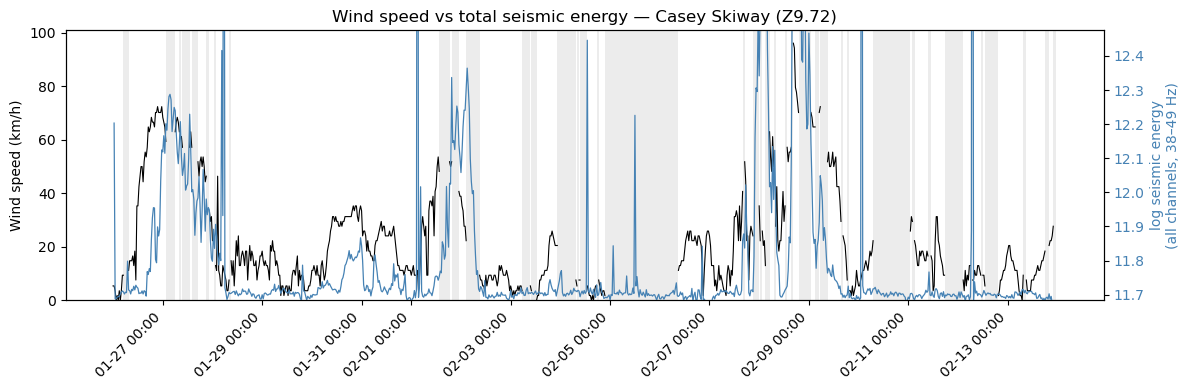

In [114]:


plot_wind_vs_energy(
    df_win, times_tot, E_tot,
    seis_label=f"log seismic energy\n(all channels, {freq[0]}–{freq[1]} Hz)",
    seis_color="steelblue",
    title=f"Wind speed vs total seismic energy — Casey Skiway ({net}.{sta})",
);



/Users/toby/miniconda3/envs/geo/lib/python3.12/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (55) of bandpass is at or above Nyquist (50.0). Applying a high-pass instead.
  warnings.warn(msg)


(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Wind speed vs total seismic energy'}, xlabel='Wind speed (km/h)', ylabel='log seismic energy'>)

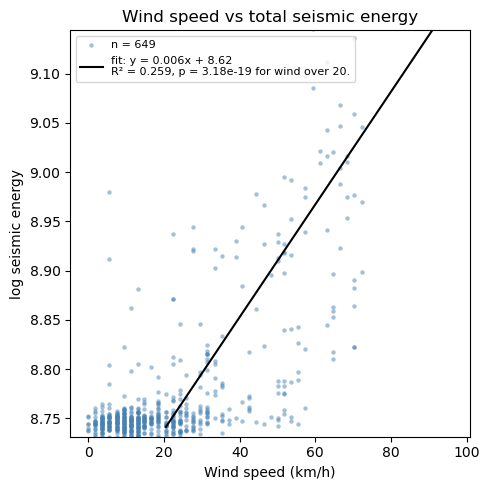

In [121]:
freq = (44, 55)

times_tot, E_tot = get_energy(st_proc, df_win["datetime"],
                               channels=["HHN", "HHE"], bp_freq=freq)


plot_wind_energy_scatter(
    df_win, times_tot, E_tot,
    wind_theshhold = 20, 
    seis_color="steelblue",
    title="Wind speed vs total seismic energy",
)

In [124]:

def monte_carlo_r2(
    st_proc,
    df_win,
    aws_col="Wind speed in km/h",
    freq_range=(5, 49),          # (fmin_min, fmax_max) Hz 49 as Nqf is 50 
    wind_range=(1, 25),          # threshold range
    channel_sets=None,           # list of channel lists to try
    n_iter=100,
    seed=42,
):
    """
    Random search over (fmin, fmax, wind_threshold, channels) to maximise R².

    Returns
    -------
    results_df : pd.DataFrame sorted by R2 descending
    """
    if channel_sets is None:
        channel_sets = [["HHN", "HHE", "HHZ"], ["HHN", "HHE"], ["HHZ"]]

    rng = random.Random(seed)
    results = []

    for i in range(n_iter):
        # sample parameters
        fmin      = rng.uniform(freq_range[0], freq_range[1] - 1)
        fmax      = rng.uniform(fmin + 1, freq_range[1])
        threshold = rng.uniform(wind_range[0], wind_range[1])
        channels  = rng.choice(channel_sets)

        try:
            times_e, energy = get_energy(
                st_proc,
                df_win["datetime"],
                channels=channels,
                bp_freq=(fmin, fmax),
            )

            energy_series = pd.Series(
                np.where(np.isfinite(energy), np.log(energy), np.nan),
                index=pd.to_datetime(times_e),
            )

            aws_series = df_win.set_index("datetime")[aws_col]
            combined   = pd.concat(
                [aws_series, energy_series.rename("energy")], axis=1
            ).dropna()

            mask = combined[aws_col].values > threshold
            if mask.sum() < 10:   # skip if too few abov
                continue

            x = combined[aws_col].values[mask]
            y = combined["energy"].values[mask]

            slope, intercept, r, p, se = linregress(x, y)

            results.append(dict(
                fmin=round(fmin, 2),
                fmax=round(fmax, 2),
                bw=round(fmax - fmin, 2),
                wind_threshold=round(threshold, 2),
                channels="+".join(channels),
                n_points=int(mask.sum()),
                slope=round(slope, 5),
                intercept=round(intercept, 4),
                r2=round(r**2, 4),
                p_value=p,
            ))

        except Exception as e:
            print(f"  [iter {i}] skipped: {e}")
            continue

        if (i + 1) % 20 == 0:
            print(f"  {i + 1}/{n_iter} done …")

    results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
    return results_df


In [126]:
mc_df = monte_carlo_r2(st_proc, df_win, n_iter=100) 
print(mc_df.head(10))


  20/100 done …
  40/100 done …
  60/100 done …
  80/100 done …
  100/100 done …
    fmin   fmax     bw  wind_threshold     channels  n_points    slope  \
0  26.73  33.07   6.34           22.80  HHN+HHE+HHZ       218  0.01742   
1  19.34  24.09   4.75           24.52  HHN+HHE+HHZ       191  0.02654   
2  15.30  24.17   8.88           14.62  HHN+HHE+HHZ       347  0.03225   
3  21.08  26.43   5.35           23.88          HHZ       218  0.01438   
4  20.23  32.65  12.41           21.73  HHN+HHE+HHZ       251  0.01865   
5   9.21  35.51  26.30           13.97  HHN+HHE+HHZ       347  0.02474   
6   9.81  46.90  37.09           17.58  HHN+HHE+HHZ       296  0.02266   
7  12.10  32.04  19.94           15.56  HHN+HHE+HHZ       318  0.02641   
8  22.48  35.76  13.29           21.75  HHN+HHE+HHZ       251  0.01547   
9  12.71  46.34  33.62           19.78      HHN+HHE       270  0.02531   

   intercept      r2       p_value  
0    11.4880  0.4237  1.167464e-27  
1    11.1429  0.4227  2.524034

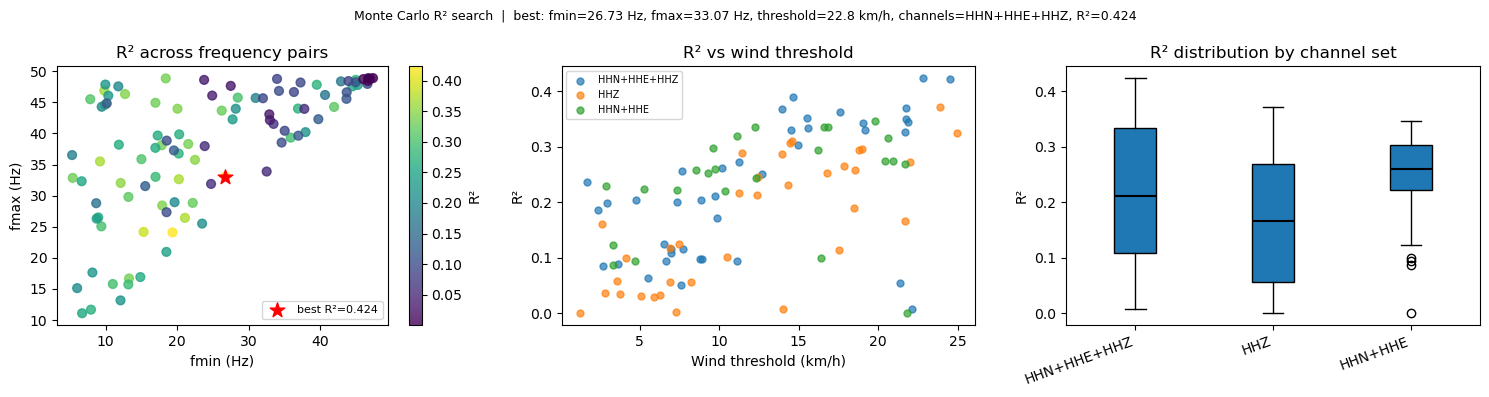

In [128]:
def plot_mc_results(mc_df):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # scatter: fmin vs fmax, coloured by R2
    ax = axes[0]
    sc = ax.scatter(mc_df["fmin"], mc_df["fmax"],
                    c=mc_df["r2"], cmap="viridis", s=40, alpha=0.8)
    fig.colorbar(sc, ax=ax, label="R²")
    ax.set_xlabel("fmin (Hz)")
    ax.set_ylabel("fmax (Hz)")
    ax.set_title("R² across frequency pairs")

    # mark best
    best = mc_df.iloc[0]
    ax.scatter(best["fmin"], best["fmax"],
               s=120, c="red", marker="*", zorder=5, label=f"best R²={best['r2']:.3f}")
    ax.legend(fontsize=8)

    # coloured by channel set
    ax = axes[1]
    channel_labels = mc_df["channels"].unique()
    cmap2 = plt.cm.tab10
    for j, cha in enumerate(channel_labels):
        sub = mc_df[mc_df["channels"] == cha]
        ax.scatter(sub["wind_threshold"], sub["r2"],
                   label=cha, s=25, alpha=0.7, color=cmap2(j))
    ax.set_xlabel("Wind threshold (km/h)")
    ax.set_ylabel("R²")
    ax.set_title("R² vs wind threshold")
    ax.legend(fontsize=7)

    # boxplot R2 by channel set 
    ax = axes[2]
    groups = [mc_df.loc[mc_df["channels"] == cha, "r2"].values
              for cha in channel_labels]
    ax.boxplot(groups, tick_labels=channel_labels, 
               patch_artist=True,
               medianprops=dict(color="black", linewidth=1.5))
    ax.set_ylabel("R²")
    ax.set_title("R² distribution by channel set")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

    fig.suptitle(
        f"Monte Carlo R² search  |  best: fmin={best['fmin']} Hz, "
        f"fmax={best['fmax']} Hz, threshold={best['wind_threshold']} km/h, "
        f"channels={best['channels']}, R²={best['r2']:.3f}",
        fontsize=9,
    )
    fig.tight_layout()

plot_mc_results(mc_df)
